# Polynomial Linear Regression

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import StandardScaler, PolynomialFeatures

from sklearn.pipeline import Pipeline

from sklearn.metrics import r2_score

In [3]:
# Generating some random data
x = 6 * np.random.rand(200, 1) - 3
y = 0.8 * x**2 + 0.9 * x + 2 + np.random.randn(200, 1) 

# It is a polynomial of degree 2
# y = 0.8x^2 + 0.9x + 2    # Equation to generate dataset and add some randomness

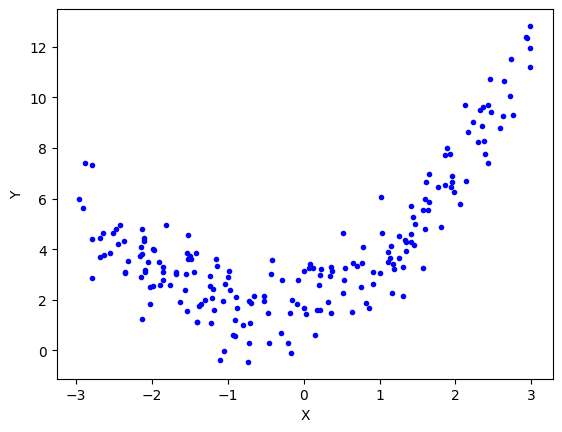

In [6]:
plt.plot(x, y, 'b.')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

### Applying SLR

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

In [8]:
lr = LinearRegression()
lr.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
y_pred = lr.predict(x_test)
r2_score(y_test, y_pred)

0.22710943674484163

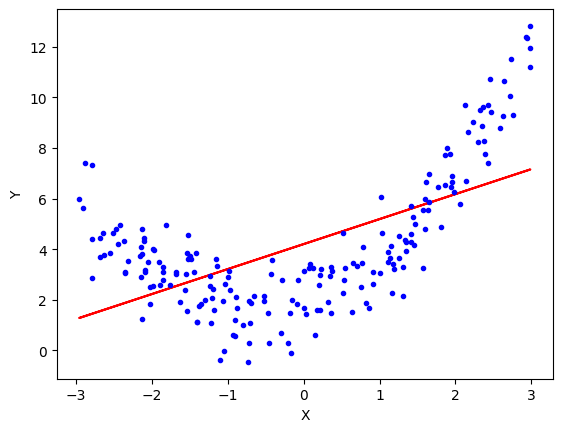

In [10]:
plt.plot(x_train, lr.predict(x_train), color='r')
plt.plot(x, y, 'b.')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

### Applying Polynomial Regression

We apply polynomial Features only on Input not output

In [24]:
# degree=2    ------ it will create 3 values of 1 column
poly = PolynomialFeatures(degree=2)
# poly = PolynomialFeatures(degree=2, include_bias=True)

x_train_trans = poly.fit_transform(x_train)
x_test_trans = poly.transform(x_test)

In [25]:
print(x_train[0])
print(x_train_trans[0])
print('x2^0, x2^1, x2^2')

[2.12476167]
[1.         2.12476167 4.51461215]
x2^0, x2^1, x2^2


In [26]:
lr.fit(x_train_trans, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
# transform test inputs with the already-fitted PolynomialFeatures, then predict
y_pred = lr.predict(x_test_trans)

In [29]:
r2_score(y_test, y_pred)

0.871670167416008

In [30]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.98549938 0.75708747]]
[2.03692601]


In [31]:
X_new=np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

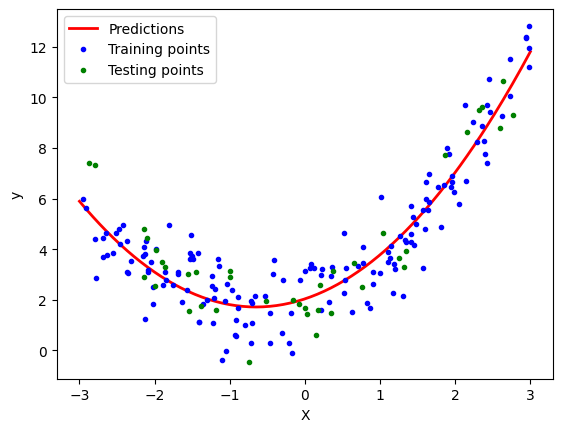

In [32]:
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(x_train, y_train, "b.", label='Training points')
plt.plot(x_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()